# Descriptive Statistics Primer

# About Dataset
The Titanic dataset contains information about **891 passengers and 12 columns** who travelled on the RMS Titanic. It includes details such as passenger ID, survival status, passenger class, name, gender, age, number of siblings or spouses aboard, number of parents or children aboard, ticket number, fare, cabin, and embarkation port. The dataset contains both numerical and categorical variables, making it useful for learning **data analysis, descriptive statistics, and data visualization**. There are missing values in the `Age`, `Cabin`, and `Embarked` columns, with `Cabin` having the highest number of missing values. In this analysis, key numerical columns such as `Age`, `Fare`, `SibSp`, `Parch`, and `Pclass` are used to calculate **mean, median, mode, standard deviation, percentiles, minimum, maximum, and IQR**. Various graphs, including bar charts, pie charts, histograms, boxplots, scatter plots, and correlation heatmaps, are also used to understand distributions, relationships, patterns, and outliers in the dataset.


In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Titanic dataset
df = pd.read_csv("titanic.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Dataset shape
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")
print(f"Total Cells       : {rows * columns}")

Number of Rows    : 891
Number of Columns : 12
Total Cells       : 10692


In [4]:
# Numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [5]:
# Calculate missing values and percentage
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_summary)

             Missing Values  Missing Percentage
PassengerId               0                0.00
Survived                  0                0.00
Pclass                    0                0.00
Name                      0                0.00
Sex                       0                0.00
Age                     177               19.87
SibSp                     0                0.00
Parch                     0                0.00
Ticket                    0                0.00
Fare                      0                0.00
Cabin                   687               77.10
Embarked                  2                0.22


In [6]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

In [7]:
# Count available observations
print(df[numeric_cols].count())

Age       714
Fare      891
SibSp     891
Parch     891
Pclass    891
dtype: int64


In [8]:
# Descriptive statistics without modifying the original data
df[numeric_cols].describe().round(3)

,Age,Fare,SibSp,Parch,Pclass
count,714.000,891.000,891.000,891.000,891.000
mean,29.699,32.204,0.523,0.382,2.309
std,14.526,49.693,1.103,0.806,0.836
min,0.420,0.000,0.000,0.000,1.000
25%,20.125,7.910,0.000,0.000,2.000
50%,28.000,14.454,0.000,0.000,3.000
75%,38.000,31.000,1.000,0.000,3.000
max,80.000,512.329,8.000,6.000,3.000


In [9]:
# Select important numeric columns
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Display selected columns
df[numeric_cols].head()

,Age,Fare,SibSp,Parch,Pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


In [10]:
# Calculate mean
mean_values = df[numeric_cols].mean()

print("Mean:")
print(mean_values)

Mean:
Age       29.699118
Fare      32.204208
SibSp      0.523008
Parch      0.381594
Pclass     2.308642
dtype: float64


In [11]:
# Calculate median
median_values = df[numeric_cols].median()

print("Median:")
print(median_values)

Median:
Age       28.0000
Fare      14.4542
SibSp      0.0000
Parch      0.0000
Pclass     3.0000
dtype: float64


In [12]:
# Calculate mode
mode_values = df[numeric_cols].mode().iloc[0]

print("Mode:")
print(mode_values)

Mode:
Age       24.00
Fare       8.05
SibSp      0.00
Parch      0.00
Pclass     3.00
Name: 0, dtype: float64


In [13]:
# Calculate sample standard deviation
std_values = df[numeric_cols].std()

print("Standard Deviation:")
print(std_values)

Standard Deviation:
Age       14.526497
Fare      49.693429
SibSp      1.102743
Parch      0.806057
Pclass     0.836071
dtype: float64


In [14]:
# Calculate important percentiles
percentiles = df[numeric_cols].quantile([0.25, 0.50, 0.75])

print("Percentiles:")
print(percentiles)

Percentiles:
         Age     Fare  SibSp  Parch  Pclass
0.25  20.125   7.9104    0.0    0.0     2.0
0.50  28.000  14.4542    0.0    0.0     3.0
0.75  38.000  31.0000    1.0    0.0     3.0


In [15]:
# Calculate minimum values
minimum = df[numeric_cols].min()

# Calculate maximum values
maximum = df[numeric_cols].max()

print("Minimum:")
print(minimum)

print("\nMaximum:")
print(maximum)

Minimum:
Age       0.42
Fare      0.00
SibSp     0.00
Parch     0.00
Pclass    1.00
dtype: float64

Maximum:
Age        80.0000
Fare      512.3292
SibSp       8.0000
Parch       6.0000
Pclass      3.0000
dtype: float64


In [16]:
# Calculate Q1 and Q3
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Interquartile Range (IQR):")
print(IQR)

Interquartile Range (IQR):
Age       17.8750
Fare      23.0896
SibSp      1.0000
Parch      0.0000
Pclass     1.0000
dtype: float64


In [17]:
# Create a summary statistics table
summary_table = pd.DataFrame({
    'Count': df[numeric_cols].count(),
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Standard Deviation': df[numeric_cols].std(),
    'Minimum': df[numeric_cols].min(),
    '25th Percentile': df[numeric_cols].quantile(0.25),
    '50th Percentile': df[numeric_cols].quantile(0.50),
    '75th Percentile': df[numeric_cols].quantile(0.75),
    'Maximum': df[numeric_cols].max(),
    'IQR': df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
})

# Round values for better readability
summary_table = summary_table.round(3)

# Display table
summary_table

,Count,Mean,Median,Mode,Standard Deviation,Minimum,25th Percentile,50th Percentile,75th Percentile,Maximum,IQR
Age,714,29.699,28.000,24.00,14.526,0.42,20.125,28.000,38.0,80.000,17.875
Fare,891,32.204,14.454,8.05,49.693,0.00,7.910,14.454,31.0,512.329,23.090
SibSp,891,0.523,0.000,0.00,1.103,0.00,0.000,0.000,1.0,8.000,1.000
Parch,891,0.382,0.000,0.00,0.806,0.00,0.000,0.000,0.0,6.000,0.000
Pclass,891,2.309,3.000,3.00,0.836,1.00,2.000,3.000,3.0,3.000,1.000


In [18]:
# Generate descriptive statistics
df[numeric_cols].describe().round(3)

,Age,Fare,SibSp,Parch,Pclass
count,714.000,891.000,891.000,891.000,891.000
mean,29.699,32.204,0.523,0.382,2.309
std,14.526,49.693,1.103,0.806,0.836
min,0.420,0.000,0.000,0.000,1.000
25%,20.125,7.910,0.000,0.000,2.000
50%,28.000,14.454,0.000,0.000,3.000
75%,38.000,31.000,1.000,0.000,3.000
max,80.000,512.329,8.000,6.000,3.000


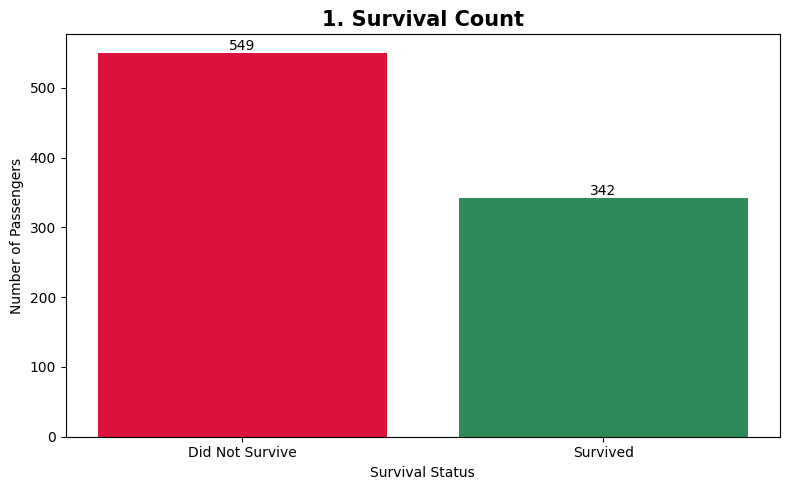

In [21]:
# ============================================================
# ANALYSIS 1: SURVIVAL COUNT
# ============================================================

survival_count = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Did Not Survive", "Survived"],
    survival_count.values,
    color=["crimson", "seagreen"]
)

plt.title("1. Survival Count", fontsize=15, fontweight="bold")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

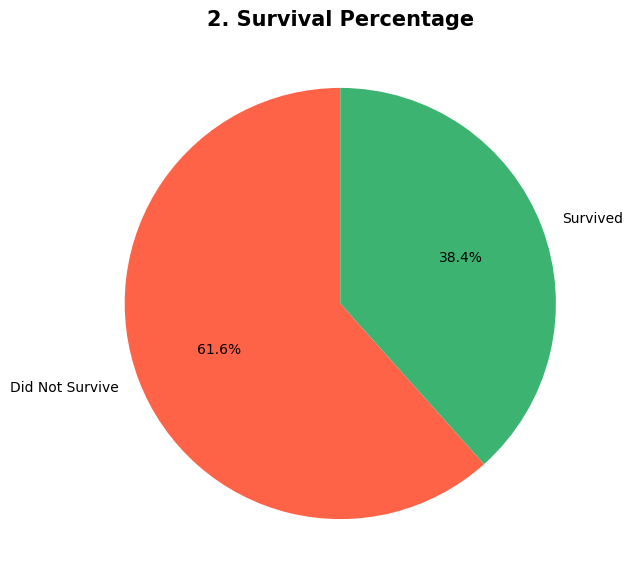

In [22]:
# ============================================================
# ANALYSIS 2: SURVIVAL PERCENTAGE
# ============================================================

survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7, 7))

plt.pie(
    survival_percentage.values,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["tomato", "mediumseagreen"]
)

plt.title("2. Survival Percentage", fontsize=15, fontweight="bold")
plt.show()

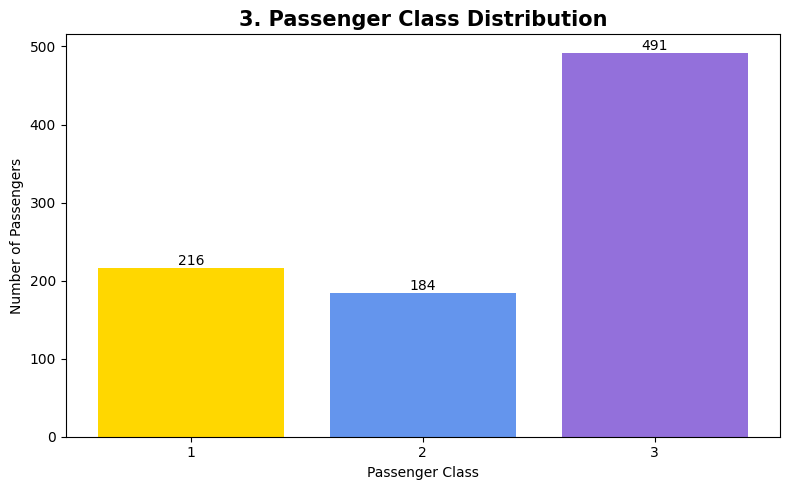

In [23]:
# ============================================================
# ANALYSIS 3: PASSENGER CLASS DISTRIBUTION
# ============================================================

pclass_count = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    pclass_count.index.astype(str),
    pclass_count.values,
    color=["gold", "cornflowerblue", "mediumpurple"]
)

plt.title("3. Passenger Class Distribution",
          fontsize=15, fontweight="bold")

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

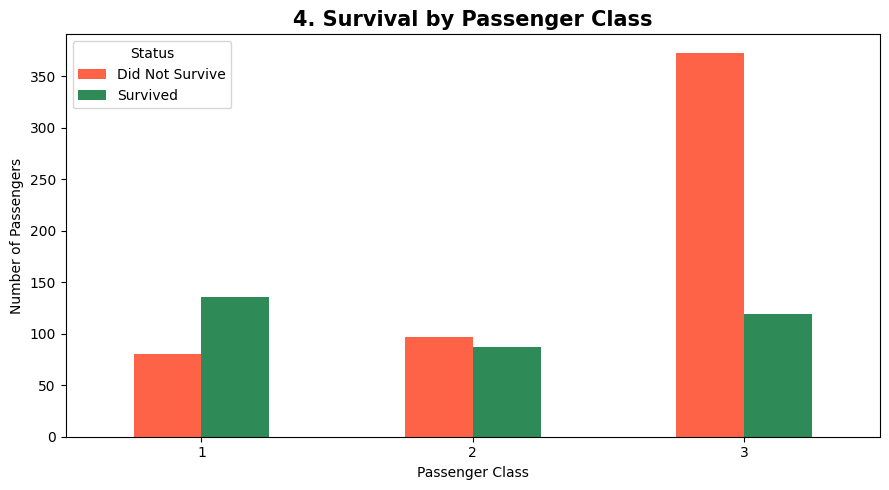

In [24]:
# ============================================================
# ANALYSIS 4: SURVIVAL BY PASSENGER CLASS
# ============================================================

survival_class = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

ax = survival_class.plot(
    kind="bar",
    figsize=(9, 5),
    color=["tomato", "seagreen"]
)

plt.title("4. Survival by Passenger Class",
          fontsize=15, fontweight="bold")

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=0)

plt.legend(
    ["Did Not Survive", "Survived"],
    title="Status"
)

plt.tight_layout()
plt.show()

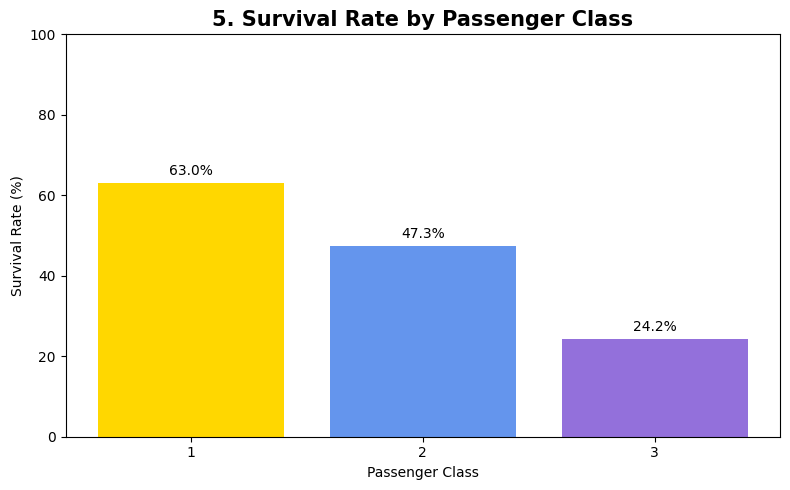

In [25]:
# ============================================================
# ANALYSIS 5: SURVIVAL RATE BY PASSENGER CLASS
# ============================================================

class_survival_rate = (
    df.groupby("Pclass")["Survived"].mean() * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_survival_rate.index.astype(str),
    class_survival_rate.values,
    color=["gold", "cornflowerblue", "mediumpurple"]
)

plt.title("5. Survival Rate by Passenger Class",
          fontsize=15, fontweight="bold")

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.ylim(0, 100)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

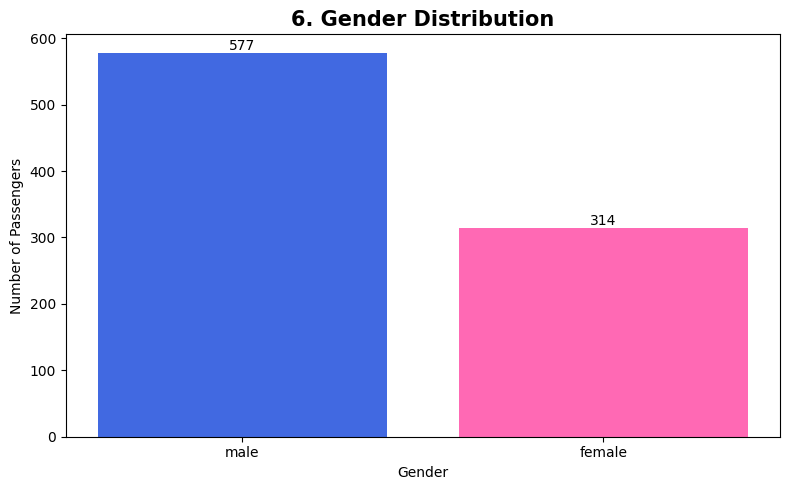

In [26]:
# ============================================================
# ANALYSIS 6: GENDER DISTRIBUTION
# ============================================================

gender_count = df["Sex"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_count.index,
    gender_count.values,
    color=["royalblue", "hotpink"]
)

plt.title("6. Gender Distribution",
          fontsize=15, fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

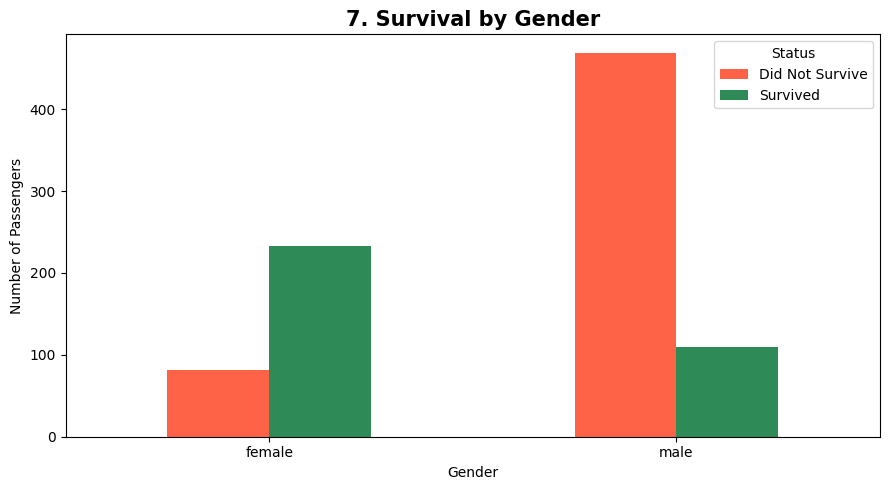

In [27]:
# ============================================================
# ANALYSIS 7: SURVIVAL BY GENDER
# ============================================================

gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

gender_survival.plot(
    kind="bar",
    figsize=(9, 5),
    color=["tomato", "seagreen"]
)

plt.title("7. Survival by Gender",
          fontsize=15, fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=0)

plt.legend(
    ["Did Not Survive", "Survived"],
    title="Status"
)

plt.tight_layout()
plt.show()

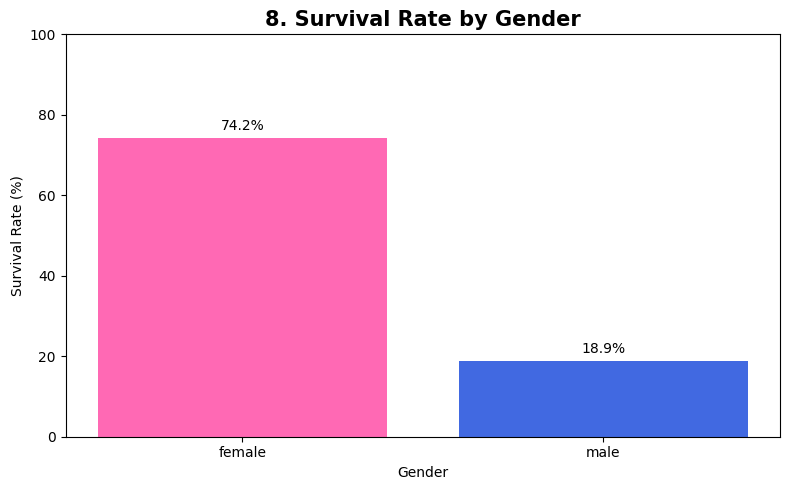

In [28]:
# ============================================================
# ANALYSIS 8: SURVIVAL RATE BY GENDER
# ============================================================

gender_survival_rate = (
    df.groupby("Sex")["Survived"].mean() * 100
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_survival_rate.index,
    gender_survival_rate.values,
    color=["hotpink", "royalblue"]
)

plt.title("8. Survival Rate by Gender",
          fontsize=15, fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.ylim(0, 100)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

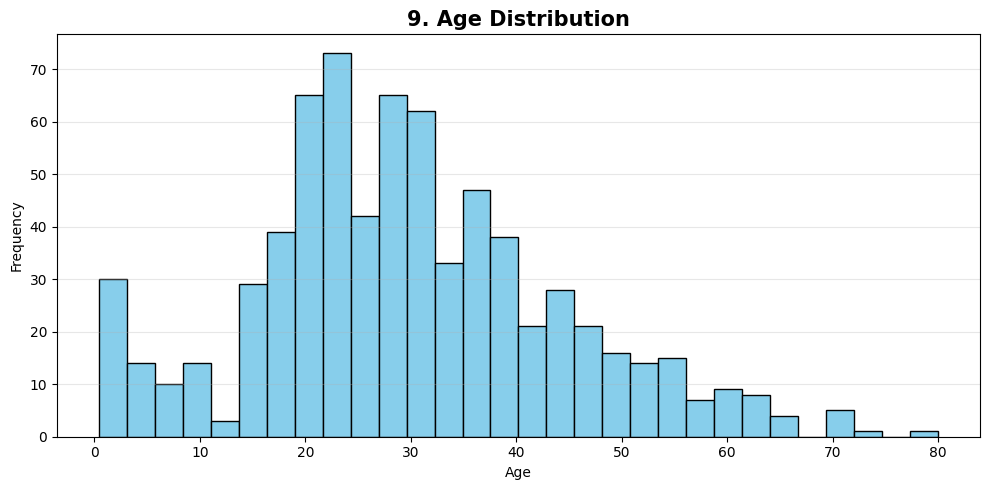

In [29]:
# ============================================================
# ANALYSIS 9: AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["Age"].dropna(),
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.title("9. Age Distribution",
          fontsize=15, fontweight="bold")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

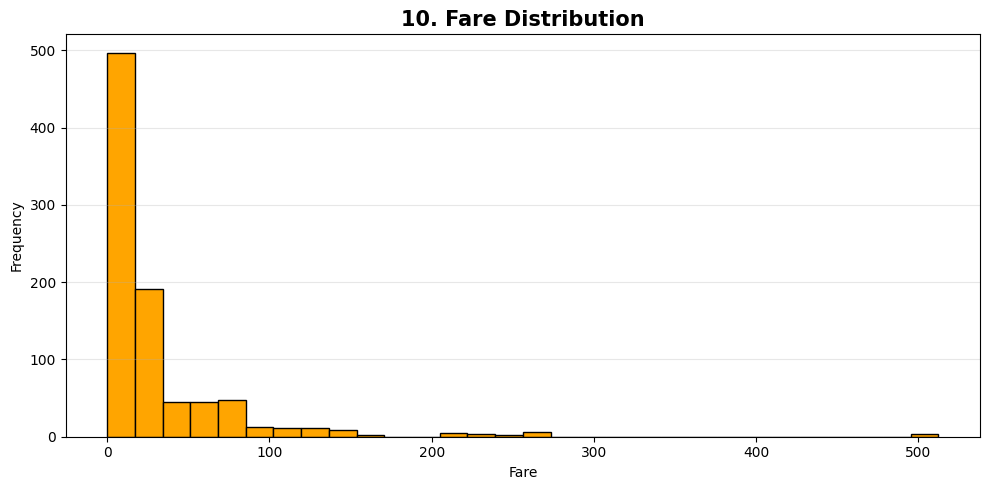

In [30]:
# ============================================================
# ANALYSIS 10: FARE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["Fare"],
    bins=30,
    color="orange",
    edgecolor="black"
)

plt.title("10. Fare Distribution",
          fontsize=15, fontweight="bold")

plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



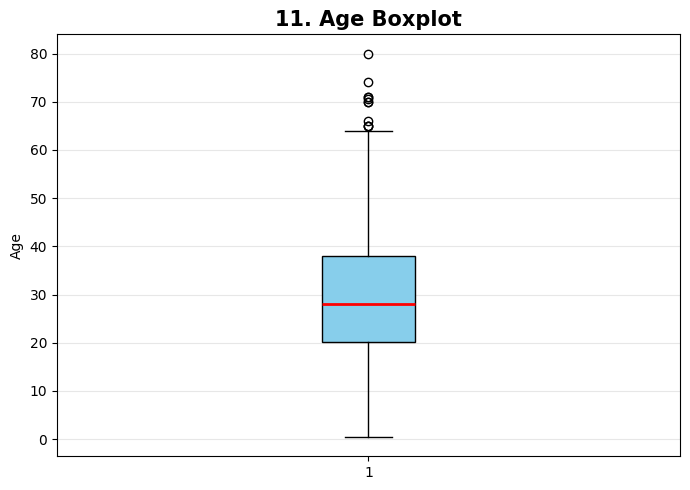

In [31]:

# ============================================================
# ANALYSIS 11: AGE BOXPLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    df["Age"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("11. Age Boxplot",
          fontsize=15, fontweight="bold")

plt.ylabel("Age")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

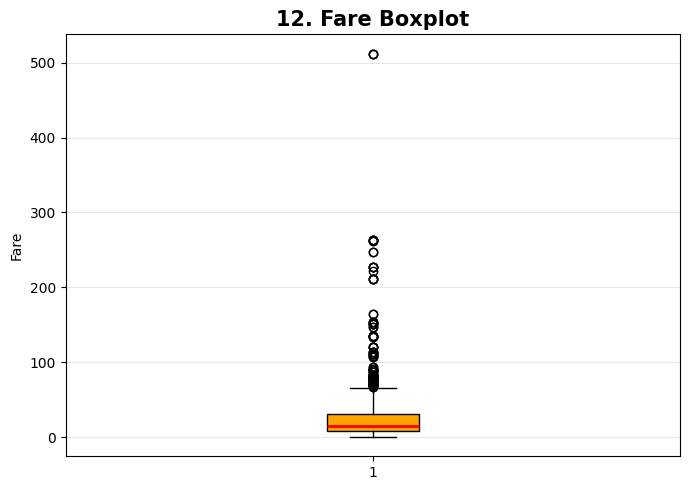

In [32]:
# ============================================================
# ANALYSIS 12: FARE BOXPLOT
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    df["Fare"],
    patch_artist=True,
    boxprops=dict(facecolor="orange"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("12. Fare Boxplot",
          fontsize=15, fontweight="bold")

plt.ylabel("Fare")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

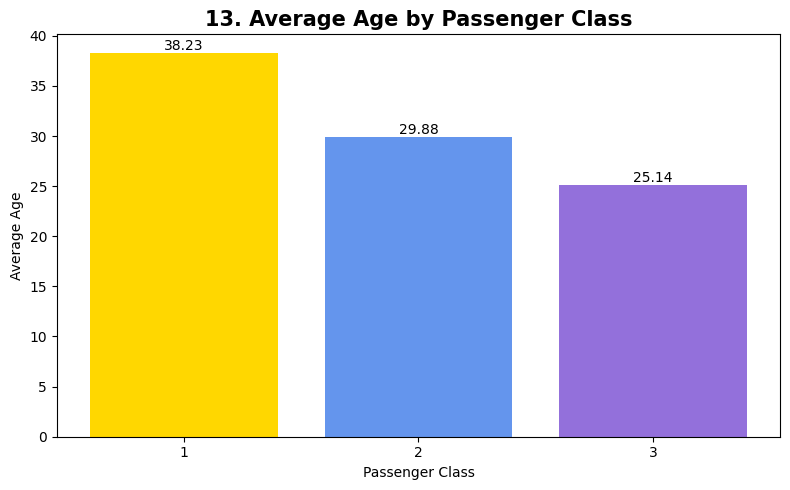

In [33]:
# ============================================================
# ANALYSIS 13: AVERAGE AGE BY PASSENGER CLASS
# ============================================================

average_age_class = (
    df.groupby("Pclass")["Age"].mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    average_age_class.index.astype(str),
    average_age_class.values,
    color=["gold", "cornflowerblue", "mediumpurple"]
)

plt.title("13. Average Age by Passenger Class",
          fontsize=15, fontweight="bold")

plt.xlabel("Passenger Class")
plt.ylabel("Average Age")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

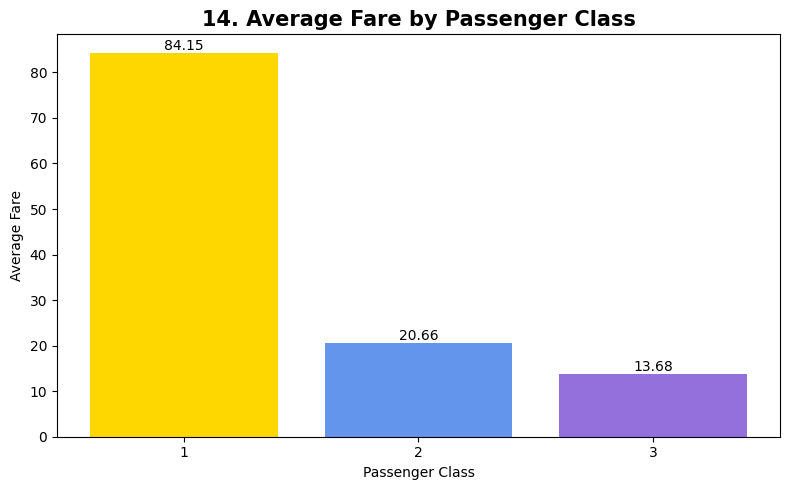

In [34]:
# ============================================================
# ANALYSIS 14: AVERAGE FARE BY PASSENGER CLASS
# ============================================================

average_fare_class = (
    df.groupby("Pclass")["Fare"].mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    average_fare_class.index.astype(str),
    average_fare_class.values,
    color=["gold", "cornflowerblue", "mediumpurple"]
)

plt.title("14. Average Fare by Passenger Class",
          fontsize=15, fontweight="bold")

plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

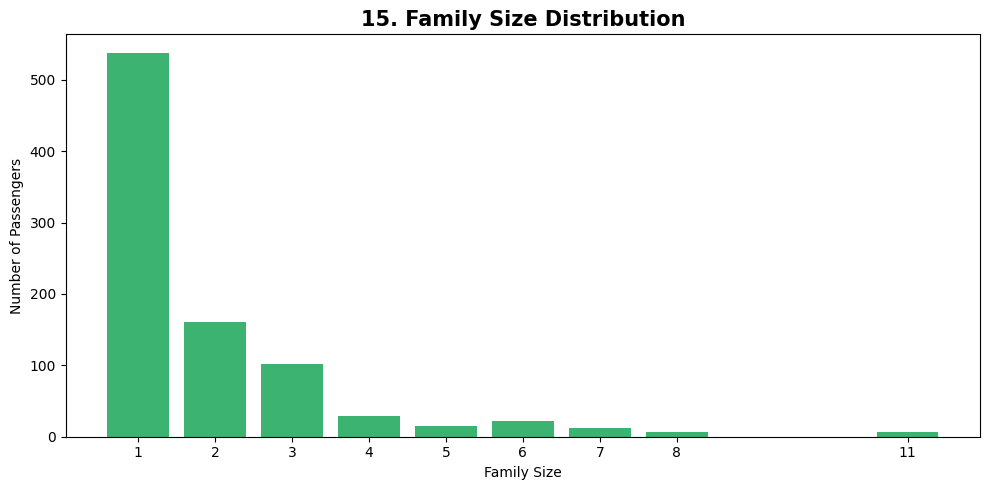

In [35]:

# ============================================================
# ANALYSIS 15: FAMILY SIZE DISTRIBUTION
# ============================================================

df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"] +
    1
)

family_size_count = (
    df["FamilySize"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    family_size_count.index,
    family_size_count.values,
    color="mediumseagreen"
)

plt.title("15. Family Size Distribution",
          fontsize=15, fontweight="bold")

plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.xticks(family_size_count.index)

plt.tight_layout()
plt.show()

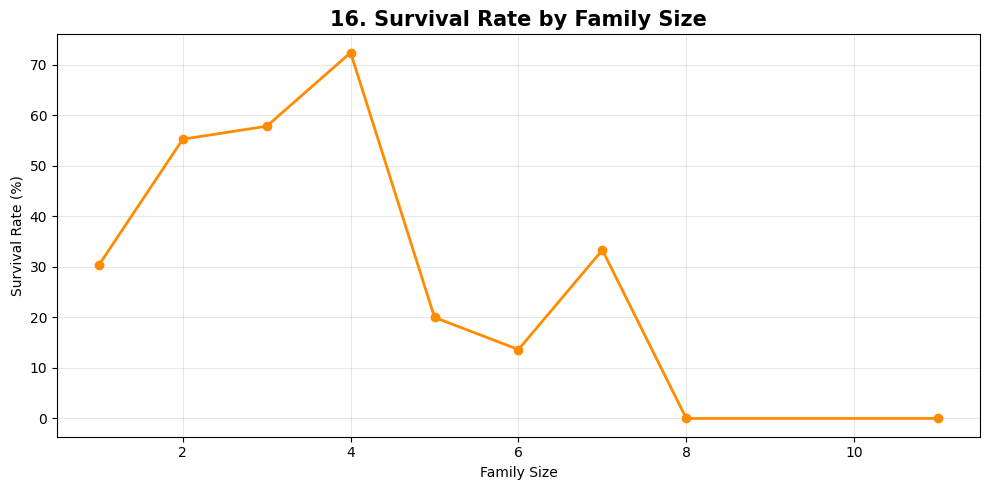

In [36]:
# ============================================================
# ANALYSIS 16: SURVIVAL RATE BY FAMILY SIZE
# ============================================================

family_survival_rate = (
    df.groupby("FamilySize")["Survived"].mean() * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    family_survival_rate.index,
    family_survival_rate.values,
    marker="o",
    linewidth=2,
    color="darkorange"
)

plt.title("16. Survival Rate by Family Size",
          fontsize=15, fontweight="bold")

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


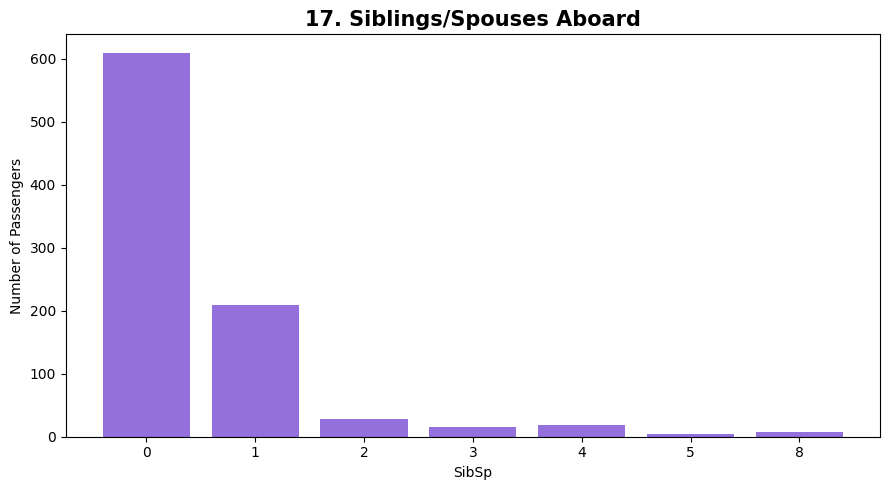

In [37]:
# ============================================================
# ANALYSIS 17: SIBLINGS / SPOUSES ABOARD
# ============================================================

sibsp_count = (
    df["SibSp"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    sibsp_count.index.astype(str),
    sibsp_count.values,
    color="mediumpurple"
)

plt.title("17. Siblings/Spouses Aboard",
          fontsize=15, fontweight="bold")

plt.xlabel("SibSp")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

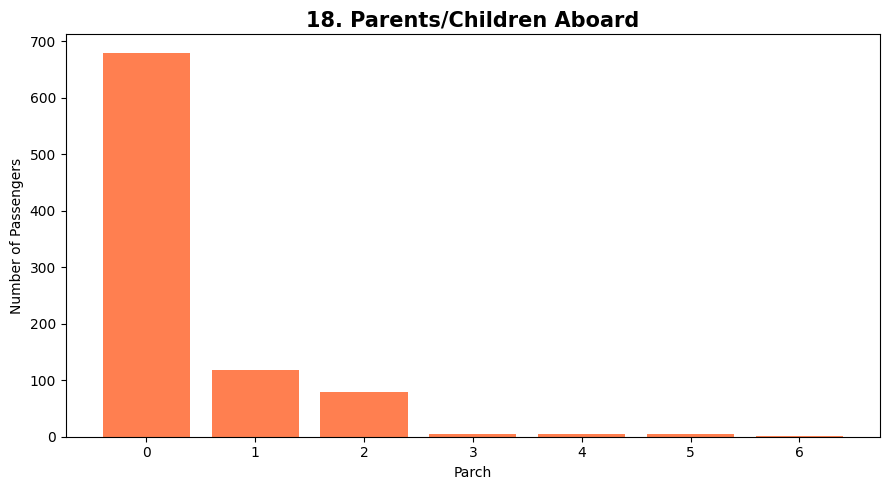

In [38]:
# ============================================================
# ANALYSIS 18: PARENTS / CHILDREN ABOARD
# ============================================================

parch_count = (
    df["Parch"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    parch_count.index.astype(str),
    parch_count.values,
    color="coral"
)

plt.title("18. Parents/Children Aboard",
          fontsize=15, fontweight="bold")

plt.xlabel("Parch")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

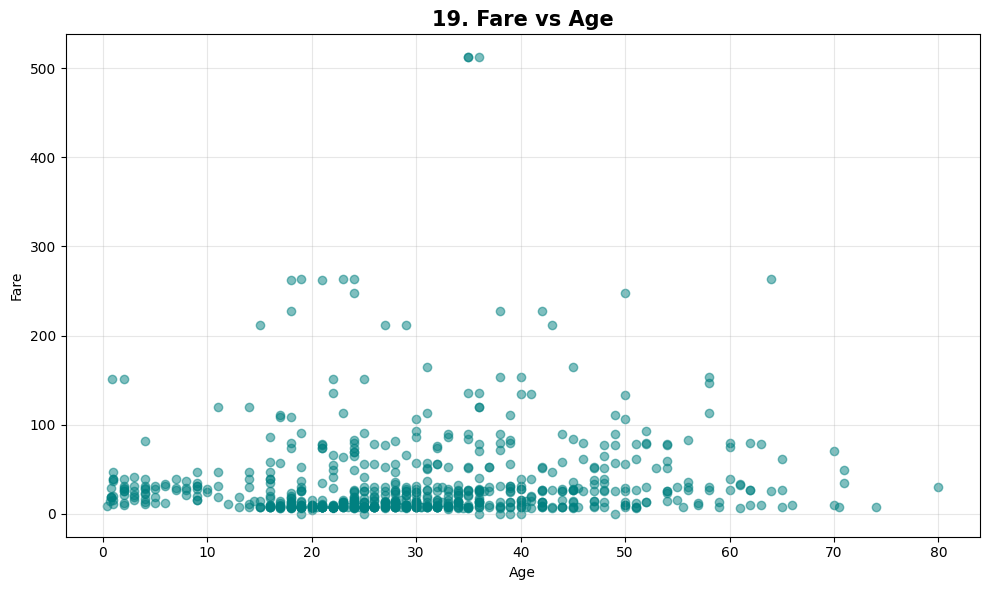

In [39]:
# ============================================================
# ANALYSIS 19: FARE VS AGE
# ============================================================

fare_age = df[["Age", "Fare"]].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    fare_age["Age"],
    fare_age["Fare"],
    alpha=0.5,
    color="teal"
)

plt.title("19. Fare vs Age",
          fontsize=15, fontweight="bold")

plt.xlabel("Age")
plt.ylabel("Fare")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

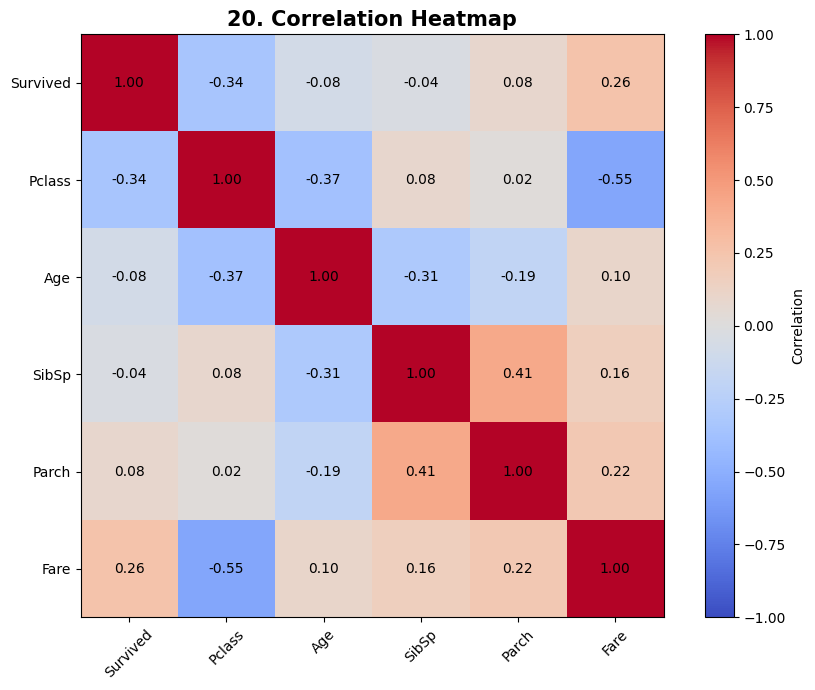

In [40]:
# ============================================================
# ANALYSIS 20: CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation = df[correlation_columns].corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title(
    "20. Correlation Heatmap",
    fontsize=15,
    fontweight="bold"
)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

numeric_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Pclass"
]

summary_statistics = pd.DataFrame({
    "Count": df[numeric_columns].count(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "25th Percentile": df[numeric_columns].quantile(0.25),
    "50th Percentile": df[numeric_columns].quantile(0.50),
    "75th Percentile": df[numeric_columns].quantile(0.75),
    "Maximum": df[numeric_columns].max()
})

# Calculate IQR
summary_statistics["IQR"] = (
    summary_statistics["75th Percentile"]
    - summary_statistics["25th Percentile"]
)

print("\n==========================================")
print("COMPLETE DESCRIPTIVE STATISTICS")
print("==========================================")

print(summary_statistics.round(3))


# ============================================================
# FINAL KEY FINDINGS
# ============================================================

print("\n==========================================")
print("KEY FINDINGS")
print("==========================================")

print(
    "\n1. Survival Rate:",
    round(df["Survived"].mean() * 100, 2),
    "%"
)

print(
    "\n2. Female Survival Rate:",
    round(
        df[df["Sex"] == "female"]["Survived"].mean() * 100,
        2
    ),
    "%"
)

print(
    "\n3. Male Survival Rate:",
    round(
        df[df["Sex"] == "male"]["Survived"].mean() * 100,
        2
    ),
    "%"
)

print("\n4. Survival Rate by Class:")
print(class_survival_rate.round(2))

print("\n5. Average Age by Class:")
print(average_age_class.round(2))

print("\n6. Average Fare by Class:")
print(average_fare_class.round(2))

print("\n7. Survival Rate by Family Size:")
print(family_survival_rate.round(2))

print("\n8. Correlation Matrix:")
print(correlation.round(2))


COMPLETE DESCRIPTIVE STATISTICS
        Count    Mean  Median   Mode  Standard Deviation  Minimum  \
Age       714  29.699  28.000  24.00              14.526     0.42   
Fare      891  32.204  14.454   8.05              49.693     0.00   
SibSp     891   0.523   0.000   0.00               1.103     0.00   
Parch     891   0.382   0.000   0.00               0.806     0.00   
Pclass    891   2.309   3.000   3.00               0.836     1.00   

        25th Percentile  50th Percentile  75th Percentile  Maximum     IQR  
Age              20.125           28.000             38.0   80.000  17.875  
Fare              7.910           14.454             31.0  512.329  23.090  
SibSp             0.000            0.000              1.0    8.000   1.000  
Parch             0.000            0.000              0.0    6.000   0.000  
Pclass            2.000            3.000              3.0    3.000   1.000  

KEY FINDINGS

1. Survival Rate: 38.38 %

2. Female Survival Rate: 74.2 %

3. Male Surviva